# Chapter 12 Exercises

These exercises turn the Chapter 12 scaling ideas into two compact PyTorch comparisons. The goal is to see how AMP behaves in practice and why correct gradient accumulation needs both loss scaling and the right optimizer-step cadence.

## Setup

In [1]:
# !pip -q install torch matplotlib  # install dependencies if needed

import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def make_toy_split(n_train=1024, n_val=256, n_features=48, n_classes=4, seed=42):
    g = torch.Generator().manual_seed(seed)
    w1 = torch.randn(n_features, 64, generator=g)
    b1 = torch.randn(64, generator=g)
    w2 = torch.randn(64, n_classes, generator=g)
    b2 = torch.randn(n_classes, generator=g)

    def sample(n):
        x = torch.randn(n, n_features, generator=g)
        hidden = torch.relu(x @ w1 + b1)
        logits = hidden @ w2 + b2 + 0.3 * torch.randn(n, n_classes, generator=g)
        y = logits.argmax(dim=1)
        return x.float(), y.long()

    return sample(n_train), sample(n_val)


(X_train, y_train), (X_val, y_val) = make_toy_split()
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)


def make_loader(dataset, batch_size, *, shuffle, seed=42):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


class TinyMLP(nn.Module):
    def __init__(self, in_features=48, hidden=96, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_model():
    return TinyMLP().to(device)


criterion = nn.CrossEntropyLoss()


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_examples += xb.size(0)

    return total_loss / total_examples, total_correct / total_examples


val_loader = make_loader(val_ds, batch_size=256, shuffle=False)
print(f"Training samples: {len(train_ds)}, validation samples: {len(val_ds)}")

Using device: cpu
Training samples: 1024, validation samples: 256


## Exercise 1

Profile a short training-step loop with AMP requested on and off. Compare runtime, inspect the computation dtype, and report memory-related information when the hardware supports it.

Mode    | Active | Avg step (ms) | Logits dtype | Peak CUDA memory (MB)
AMP off | False  |         0.239 | float32      |                   n/a
AMP on  | False  |         0.249 | float32      |                   n/a


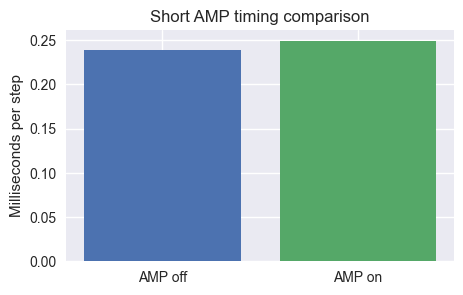

Takeaway: this notebook is running on CPU, so AMP stays inactive and the timings are mainly a control check. The biggest AMP benefits usually appear on supported GPUs.


In [2]:
def benchmark_amp(request_amp, steps=80, batch_size=256):
    set_seed(42)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    xb = torch.randn(batch_size, X_train.shape[1], device=device)
    yb = torch.randint(0, 4, (batch_size,), device=device)
    amp_active = request_amp and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_active)

    for _ in range(5):
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=amp_active):
            logits = model(xb)
            loss = criterion(logits, yb)
        if amp_active:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

    if device.type == "cuda":
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats(device)

    start = time.perf_counter()
    for _ in range(steps):
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=amp_active):
            logits = model(xb)
            loss = criterion(logits, yb)
        if amp_active:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    peak_memory_mb = None
    if device.type == "cuda":
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    return {
        "label": "AMP on" if request_amp else "AMP off",
        "amp_active": amp_active,
        "step_ms": 1000 * elapsed / steps,
        "peak_memory_mb": peak_memory_mb,
        "dtype": str(logits.dtype).replace("torch.", ""),
    }


amp_results = [benchmark_amp(False), benchmark_amp(True)]

print("Mode    | Active | Avg step (ms) | Logits dtype | Peak CUDA memory (MB)")
for row in amp_results:
    memory_text = f"{row['peak_memory_mb']:.1f}" if row['peak_memory_mb'] is not None else "n/a"
    print(
        f"{row['label']:<7} | {str(row['amp_active']):<6} | {row['step_ms']:>13.3f} | {row['dtype']:<12} | {memory_text:>21}"
    )

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(
    [row["label"] for row in amp_results],
    [row["step_ms"] for row in amp_results],
    color=["#4C72B0", "#55A868"],
)
ax.set_ylabel("Milliseconds per step")
ax.set_title("Short AMP timing comparison")
plt.show()

if device.type == "cuda":
    faster = min(amp_results, key=lambda row: row["step_ms"])
    print(
        f"Takeaway: on this CUDA run, {faster['label']} was faster. AMP is worth profiling because it can change both step time and peak GPU memory."
    )
else:
    print(
        "Takeaway: this notebook is running on CPU, so AMP stays inactive and the timings are mainly a control check. The biggest AMP benefits usually appear on supported GPUs."
    )

## Exercise 2

Accumulate gradients over four micro-batches of size 64 and compare that result with a true batch size of 256. Then break the recipe once by skipping loss scaling and once by stepping every micro-batch.

Run                        | Opt steps | Param diff vs ref | Max logit diff
Large batch 256            |         2 |          0.000000 |       0.000000
Accum 64x4 (correct)       |         2 |          0.000000 |       0.000000
Accum 64x4 (no scaling)    |         2 |          0.076971 |       0.097407
Micro-batch 64 (step each) |         8 |          0.073845 |       0.092785


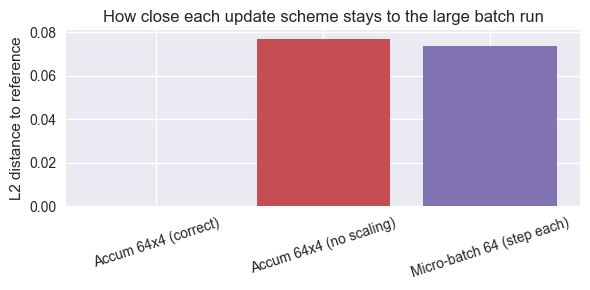

Takeaway: accumulation matches the large-batch reference only when you delay the optimizer step until the full accumulation window and scale the loss by the number of micro-batches.


In [3]:
eq_X = X_train[:512]
eq_y = y_train[:512]
probe_x = X_val[:64].to(device)

base_model = make_model()
base_state = copy.deepcopy(base_model.state_dict())


def flatten_params(model):
    return torch.cat([param.detach().cpu().reshape(-1) for param in model.parameters()])


def run_update_scheme(name, micro_batch, step_every, *, scale_loss):
    model = make_model()
    model.load_state_dict(copy.deepcopy(base_state))
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
    optimizer.zero_grad(set_to_none=True)
    optimizer_steps = 0

    for batch_index, start in enumerate(range(0, len(eq_X), micro_batch), start=1):
        xb = eq_X[start : start + micro_batch].to(device)
        yb = eq_y[start : start + micro_batch].to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        if scale_loss:
            loss = loss / step_every
        loss.backward()

        if batch_index % step_every == 0:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_steps += 1

    if len(eq_X) // micro_batch % step_every != 0:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        optimizer_steps += 1

    return {
        "name": name,
        "optimizer_steps": optimizer_steps,
        "params": flatten_params(model),
        "probe_logits": model(probe_x).detach().cpu(),
    }


reference = run_update_scheme("Large batch 256", micro_batch=256, step_every=1, scale_loss=False)
comparisons = [
    reference,
    run_update_scheme("Accum 64x4 (correct)", micro_batch=64, step_every=4, scale_loss=True),
    run_update_scheme("Accum 64x4 (no scaling)", micro_batch=64, step_every=4, scale_loss=False),
    run_update_scheme("Micro-batch 64 (step each)", micro_batch=64, step_every=1, scale_loss=False),
]

print("Run                        | Opt steps | Param diff vs ref | Max logit diff")
for row in comparisons:
    param_diff = (row["params"] - reference["params"]).norm().item()
    logit_diff = (row["probe_logits"] - reference["probe_logits"]).abs().max().item()
    print(
        f"{row['name']:<26} | {row['optimizer_steps']:>9} | {param_diff:>17.6f} | {logit_diff:>14.6f}"
    )

fig, ax = plt.subplots(figsize=(6, 3))
labels = [row["name"] for row in comparisons[1:]]
param_diffs = [(row["params"] - reference["params"]).norm().item() for row in comparisons[1:]]
ax.bar(labels, param_diffs, color=["#55A868", "#C44E52", "#8172B2"])
ax.set_ylabel("L2 distance to reference")
ax.set_title("How close each update scheme stays to the large batch run")
ax.tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

print(
    "Takeaway: accumulation matches the large-batch reference only when you delay the optimizer step until the full accumulation window and scale the loss by the number of micro-batches."
)

## Summary

- AMP is easy to benchmark with a short repeated step loop, but meaningful speed and memory gains usually show up on supported GPUs.
- Gradient accumulation is a bookkeeping trick for effective batch size, not a free-for-all: both the loss scaling and the optimizer-step cadence matter.
- Small synthetic runs are enough to validate the training logic before using the same ideas on a larger model or dataset.